# Leafs Lab — an honest forecasting workflow
## Executed results
Official NHL data: 5,256 games and 1,278,937 regulation states.
The September 30 2–1 state received an 85.9% modeled win probability.
The calibrated model did not beat the simpler baseline on held-out Brier
score. The season forecasts are exploratory, with retrospective limitations.
This notebook reads saved real-data outputs and exposes the caveats.


In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
try:
    from IPython.display import display, Markdown, Image
except ImportError:
    def display(value): print(value)
    def Markdown(text): return text
    def Image(filename): return 'Image artifact: '+filename
ROOT = Path.cwd()
if not (ROOT / 'config.json').exists():
    raise RuntimeError('Open the extracted leafs-lab folder as your working directory.')
config = json.loads((ROOT / 'config.json').read_text())
ready = (ROOT / 'data/states.csv').exists()
print('Verified dataset available:', ready)
if not ready:
    print('BLOCKED: run python -m leafslab run with NHL source access. No data/results substituted.')


Verified dataset available: True


## Context and methods
Outcome: eventual home-team win, including OT/shootout. Observations are
nonterminal regulation post-event states. Training and test are separated by
season, with distinct tuning and calibration dates. Equal total game weights
prevent a high-event game dominating the evaluation.

### Key assumptions
Elo uses past dates only. Goalies/skaters are observed situation codes,
with explicit missingness. Future season strength is fixed. Simulation error
intervals are not full model confidence intervals.


In [2]:
display(pd.DataFrame([
    {'partition': 'Training', 'seasons': str(config['train_seasons'])},
    {'partition': 'Tuning', 'seasons': str(config['validation_season'])+' first half of dates'},
    {'partition': 'Calibration', 'seasons': str(config['validation_season'])+' second half of dates'},
    {'partition': 'Untouched test', 'seasons': str(config['test_season'])}
]))


,partition,seasons
0,Training,"[20222023, 20232024]"
1,Tuning,20242025 first half of dates
2,Calibration,20242025 second half of dates
3,Untouched test,20252026


## Data and EDA
Check season coverage before interpreting distributions. Missingness and
exclusions are part of the result. Final labels are not input features.


In [3]:
if ready:
    states = pd.read_csv(ROOT / 'data/states.csv')
    quality = json.loads((ROOT / 'outputs/data_quality.json').read_text())
    display(pd.DataFrame(quality['coverage_by_season']).T)
    display(states.head(10))
    display(states.groupby('season').agg(games=('game_id','nunique'),states=('game_id','size')))
    display(states.isna().sum().rename('missing').to_frame())
    assert not states[['game_id','elapsed']].duplicated().any()
    assert states.groupby('game_id').weight.sum().between(.999999,1.000001).all()
    assert states.elapsed.lt(3600).all()
else:
    print('EDA not executed: official historical observations unavailable.')


,eligible_games,parsed_games,coverage
20222023,1312.0,1312.0,1.0
20232024,1312.0,1312.0,1.0
20242025,1312.0,1312.0,1.0
20252026,1312.0,1312.0,1.0


,game_id,season,date,home,away,elapsed,event,home_goals,away_goals,goal_diff,remaining,shot_diff,skater_diff,home_empty,away_empty,situation_missing,pregame_logit,home_win,goal_at_second,score_clock,weight
0,2022020001,20222023,2022-10-07,NSH,SJS,0,faceoff,0,0,0,1.000000,0,0,0,0,0,0.259041,1,0,0.0,0.004132
1,2022020001,20222023,2022-10-07,NSH,SJS,11,hit,0,0,0,0.996944,0,0,0,0,0,0.259041,1,0,0.0,0.004132
2,2022020001,20222023,2022-10-07,NSH,SJS,17,hit,0,0,0,0.995278,0,0,0,0,0,0.259041,1,0,0.0,0.004132
3,2022020001,20222023,2022-10-07,NSH,SJS,23,shot-on-goal,0,0,0,0.993611,-1,0,0,0,0,0.259041,1,0,0.0,0.004132
4,2022020001,20222023,2022-10-07,NSH,SJS,24,faceoff,0,0,0,0.993333,-1,0,0,0,0,0.259041,1,0,0.0,0.004132
5,2022020001,20222023,2022-10-07,NSH,SJS,36,missed-shot,0,0,0,0.990000,-1,0,0,0,0,0.259041,1,0,0.0,0.004132
6,2022020001,20222023,2022-10-07,NSH,SJS,42,giveaway,0,0,0,0.988333,-1,0,0,0,0,0.259041,1,0,0.0,0.004132
7,2022020001,20222023,2022-10-07,NSH,SJS,49,hit,0,0,0,0.986389,-1,0,0,0,0,0.259041,1,0,0.0,0.004132
8,2022020001,20222023,2022-10-07,NSH,SJS,56,blocked-shot,0,0,0,0.984444,-1,0,0,0,0,0.259041,1,0,0.0,0.004132
9,2022020001,20222023,2022-10-07,NSH,SJS,59,shot-on-goal,0,0,0,0.983611,0,0,0,0,0,0.259041,1,0,0.0,0.004132


,games,states
season,,
20222023,1312,307576
20232024,1312,320547
20242025,1312,327699
20252026,1312,321124
20262027,8,1991


,missing
game_id,0
season,0
date,0
home,0
away,0
elapsed,0
event,0
home_goals,0
away_goals,0
goal_diff,0


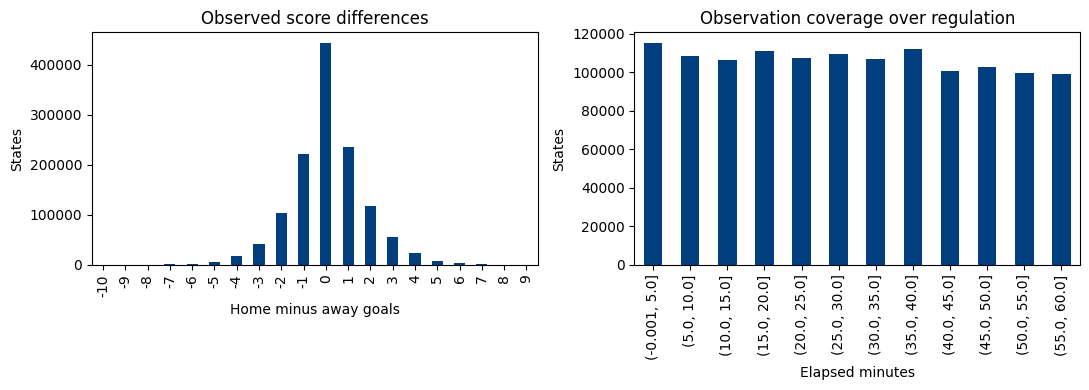

In [4]:
if ready:
    import matplotlib.pyplot as plt
    figure, axes = plt.subplots(1, 2, figsize=(11, 4))
    states.goal_diff.value_counts().sort_index().plot.bar(ax=axes[0], color='#003e7e')
    axes[0].set(title='Observed score differences', xlabel='Home minus away goals', ylabel='States')
    states.groupby(pd.cut(states.elapsed/60, range(0,61,5), include_lowest=True), observed=True).size().plot.bar(ax=axes[1], color='#003e7e')
    axes[1].set(title='Observation coverage over regulation', xlabel='Elapsed minutes', ylabel='States')
    figure.tight_layout()
    display(figure)
    plt.close(figure)


## Model results and validation
Logistic regression and histogram gradient boosting are selected by tuning
Brier score, then calibrated on a later independent period. Test metrics
describe a frozen pipeline. Never select a model using these test results.
AUC measures discrimination; Brier/log loss assess probability quality.


In [5]:
if (ROOT / 'outputs/metrics.json').exists():
    metrics = json.loads((ROOT / 'outputs/metrics.json').read_text())
    assert metrics['status'] == 'real_data_evaluated', 'Fixture results are not analysis'
    display(pd.DataFrame(metrics['test']).T)
    display(pd.DataFrame(metrics['calibration']))
    display(pd.DataFrame(metrics['feature_importance']).sort_values('brier_increase', ascending=False))
    print('Paired game-bootstrap comparison:', metrics['paired_bootstrap'])
    print('Held-out 80–90% home-leading cohort:', metrics['instinct_cohort'])
else:
    print('Model training/evaluation not executed on real NHL observations.')


Paired game-bootstrap comparison: {'brier_difference': 0.0021777382709809116, '95_percent_game_bootstrap_interval': [-0.0007923612567853561, 0.0050571473567707125], 'bootstrap_draws': 400, 'interpretation': 'Negative favors selected model; interval crossing zero is inconclusive.'}
Held-out 80–90% home-leading cohort: {'games': 679, 'mean_prediction': 0.8508650484913747, 'observed_rate': 0.801178203240059, '95_percent_game_bootstrap_interval': [0.7717231222385862, 0.8291605301914581]}


,brier,log_loss,auc,accuracy
baseline,0.176329,0.516596,0.808607,0.706405
selected_raw,0.177000,0.517592,0.807338,0.707381
selected_calibrated,0.178507,0.520925,0.807338,0.712970
pregame_only,0.251880,0.697914,0.547629,0.538872
constant_50_percent,0.250000,0.693147,0.500000,0.522104


,bin,mean_prediction,observed_rate,games,states
0,0,0.037299,0.039543,537,26418
1,1,0.150164,0.145808,578,18784
2,2,0.251013,0.256222,570,19397
3,3,0.350191,0.311144,614,25516
4,4,0.455549,0.425356,590,29192
5,5,0.552615,0.507158,862,57128
6,6,0.644706,0.559311,687,39791
7,7,0.751968,0.690316,729,33483
8,8,0.849919,0.811654,680,28803
9,9,0.961323,0.963405,616,42612


,feature,brier_increase
2,score_clock,0.120026
3,pregame_logit,0.002394
0,goal_diff,0.001823
5,skater_diff,0.000043
4,shot_diff,0.000034
8,situation_missing,0.000000
6,home_empty,-0.000024
1,remaining,-0.000028
7,away_empty,-0.000030


## Game reconstruction and explanations
Examine the first verified 2–1 post-goal state, rather than searching for a
convenient high probability. Scenario contrasts are noncausal/nonadditive.


2026-09-30 TOR vs NYI
First 2–1 state: {'game_id': 2026020008, 'season': 20262027, 'date': '2026-09-30', 'home': 'TOR', 'away': 'NYI', 'elapsed': 3249, 'event': 'faceoff', 'home_goals': 2, 'away_goals': 1, 'goal_diff': 1, 'remaining': 0.0975, 'shot_diff': 0, 'skater_diff': 1, 'home_empty': 0, 'away_empty': 0, 'situation_missing': 0, 'pregame_logit': -0.1365399510187003, 'home_win': 1, 'goal_at_second': 1, 'score_clock': 2.857142857142857, 'weight': 0.004132231404958678, 'home_probability': 0.8590580369829669, 'toronto_probability': 0.8590580369829669}


,feature,alternative_value,alternative_probability,difference_percentage_points
0,goal_diff,0,0.508283,35.077495
1,pregame_logit,0,0.870337,-1.127890
2,skater_diff,0,0.851121,0.793703
3,home_empty,0,0.859058,0.000000
4,away_empty,0,0.859058,0.000000


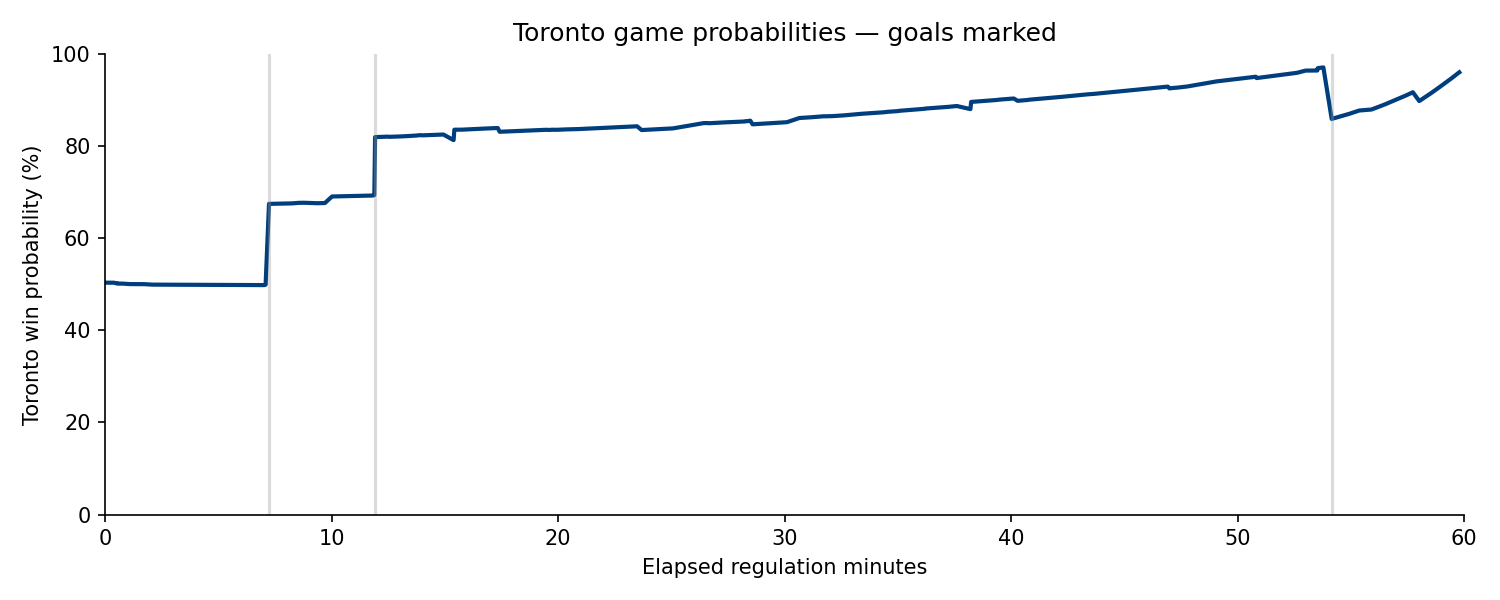

In [6]:
if (ROOT / 'outputs/game_explanation.json').exists():
    game = json.loads((ROOT / 'outputs/game_explanation.json').read_text())
    print(game['date'], game['home'], 'vs', game['away'])
    print('First 2–1 state:', game['first_2_1_state'])
    if game['explanation']:
        display(pd.DataFrame(game['explanation']['contrasts']))
    if (ROOT / 'outputs/figures/game_probability.png').exists():
        display(Image(filename=str(ROOT / 'outputs/figures/game_probability.png')))
else:
    print('Game reconstruction awaiting official PBP and a trained model.')


## Team ratings and season forecast
Simulation includes current standings, the remaining schedule, division and
wildcard qualification, overtime points, and four best-of-seven rounds.
Forecast stage probabilities are unconditional. ±50 Elo is a strength
sensitivity analysis; it is not a comprehensive uncertainty interval.


In [7]:
if (ROOT / 'outputs/forecast.json').exists():
    forecast = json.loads((ROOT / 'outputs/forecast.json').read_text())
    assert forecast['status'] == 'real_data_simulated'
    teams = pd.DataFrame(forecast['teams']).sort_values('cup', ascending=False)
    display(teams)
    display(teams[teams.team.eq('TOR')])
    print('As of:', forecast['as_of'], 'Simulations:', forecast['simulations'])
    print('Toronto sensitivity:', forecast.get('sensitivity'))
    assert np.isclose(teams.cup.sum(), 1)
    assert np.isclose(teams.playoffs.sum(), 16)
    print('\n'.join(forecast['assumptions']))
else:
    print('Season forecast not executed: no Cup percentage available.')


As of: 2026-10-01 Simulations: 10000
Toronto sensitivity: [{'toronto_elo_change': -50, 'playoffs': 0.049, 'cup': 0.0, 'simulations': 2000}, {'toronto_elo_change': 50, 'playoffs': 0.3005, 'cup': 0.0125, 'simulations': 2000}]
One latent team-strength draw per simulated season; SD estimated from training-season Elo drift, not a calibrated posterior. No explicit injury, lineup or trade adjustments.
Independent Poisson regulation goals; all simulated ties resolve in overtime.
Standings ties approximate official rules: no head-to-head tie-break.
Playoff game probabilities use regular-season Elo; no separate playoff fit.
Cup intervals show simulation error only, not forecasting/model uncertainty.


,team,elo,mean_points,points_p10,points_p90,playoffs,round_2,conference_final,final,cup,cup_mc_95_interval,cup_simulation_wins
7,COL,1580.086572,107.3811,87.0,127.0,0.8670,0.5576,0.3276,0.2224,0.1180,"[0.11182308608963513, 0.12447029944337847]",1180
3,CAR,1571.669782,103.6566,83.0,124.0,0.7536,0.4560,0.2717,0.1458,0.0895,"[0.08406139460840494, 0.09525387963584138]",895
2,BUF,1578.057001,105.0624,85.0,125.0,0.7665,0.4464,0.2535,0.1475,0.0888,"[0.08338142541390162, 0.09453438644781356]",888
14,MTL,1574.549380,104.8803,84.0,125.0,0.7633,0.4269,0.2303,0.1310,0.0806,"[0.07542413989407339, 0.08609796977227717]",806
8,DAL,1558.333090,102.5293,82.0,123.0,0.7933,0.4581,0.2506,0.1583,0.0778,"[0.07271064543581152, 0.08321361470041452]",778
25,TBL,1554.397317,100.6185,80.0,121.0,0.6744,0.3569,0.1783,0.0979,0.0592,"[0.05474149067846031, 0.06399705472193866]",592
19,OTT,1545.028040,98.4969,78.0,119.0,0.6192,0.3038,0.1512,0.0739,0.0423,"[0.03852766036149848, 0.046423864660648996]",423
13,MIN,1529.345319,96.9418,76.0,117.0,0.6790,0.3330,0.1641,0.0920,0.0395,"[0.035855763421720276, 0.0434979120703027]",395
31,WSH,1535.235841,96.8049,76.0,117.0,0.6061,0.3174,0.1531,0.0684,0.0369,"[0.03337934852725074, 0.04077632382965663]",369
20,PHI,1527.894281,94.1923,73.0,115.0,0.5386,0.2817,0.1392,0.0646,0.0367,"[0.033189052940687025, 0.04056677302121145]",367


,team,elo,mean_points,points_p10,points_p90,playoffs,round_2,conference_final,final,cup,cup_mc_95_interval,cup_simulation_wins
26,TOR,1432.987801,76.1688,56.0,97.0,0.1398,0.0412,0.0164,0.0067,0.0025,"[0.0016939856428771645, 0.003688106772500543]",25


## Season backtest and takeaways
Game win-probability accuracy is not championship forecast accuracy.
One held-out season supplies a diagnostic, not reliable Cup calibration.
A defensible LinkedIn claim includes the held-out baseline comparison,
observed data coverage, forecast date, and relevant assumptions.


In [8]:
if (ROOT / 'outputs/season_backtest_metrics.json').exists():
    season_test = json.loads((ROOT / 'outputs/season_backtest_metrics.json').read_text())
    for result in season_test['seasons']:
        print('Backtest season:', result['season'])
        display(pd.DataFrame(result['probability_scores']).T)
        print('Points MAE:', result['points_mae'], 'RMSE:', result['points_rmse'])
    print('Average points MAE:', season_test['mean_points_mae'])
    print(season_test['warning'])
else:
    print('No held-out season simulation evaluation available yet.')
if (ROOT / 'outputs/report.md').exists():
    display(Markdown((ROOT / 'outputs/report.md').read_text().replace('](figures/', '](outputs/figures/')))
else:
    print('Conclusion: implementation exists; forecasting claims remain unverified until real-data execution.')

Backtest season: 20232024
Points MAE: 9.396106249999999 RMSE: 11.226800408258576
Backtest season: 20242025
Points MAE: 10.02113125 RMSE: 12.215776705479065
Backtest season: 20252026
Points MAE: 12.894559375 RMSE: 15.530211527445061
Average points MAE: 10.770598958333332
Three seasons provide a diagnostic, not established Cup calibration; outcomes within each season are dependent.


,brier,clubs,positives
playoffs,0.155914,32.0,16.0
round_2,0.128910,32.0,8.0
conference_final,0.102491,32.0,4.0
final,0.056703,32.0,2.0
cup,0.032499,32.0,1.0


,brier,clubs,positives
playoffs,0.215566,32.0,16.0
round_2,0.135805,32.0,8.0
conference_final,0.081688,32.0,4.0
final,0.054370,32.0,2.0
cup,0.028657,32.0,1.0


,brier,clubs,positives
playoffs,0.271459,32.0,16.0
round_2,0.211170,32.0,8.0
conference_final,0.105068,32.0,4.0
final,0.057656,32.0,2.0
cup,0.030879,32.0,1.0


# Leafs Lab: executed results

Snapshot: 2026-10-01. Experimental model-based season forecast. The latest retrospective playoff Brier score is above the 0.25 naive baseline; these percentages are exploratory.

Toronto: playoffs **14.0%**, Final **0.7%**, Cup **0.2%**.
Cup Monte Carlo interval: 0.2%–0.4%. This interval measures simulation error only.

## Game-model validation
Selected model: logistic_C1. Untouched test season: 20252026.
Game-weighted Brier: selected/calibrated **0.1785**, score/time baseline **0.1763**.
Paired Brier-difference interval: -0.0008 to 0.0051. Improvement over baseline is not established by the bootstrap interval.

![Game reconstruction](outputs/figures/game_probability.png)
![Calibration](outputs/figures/calibration.png)
![Model comparison](outputs/figures/model_comparison.png)
![Cup forecast](outputs/figures/cup_forecast.png)

## Season-model evaluation
Retrospective preseason checks cover three seasons. Model parameters were revised after reviewing the initial fixed-strength baseline; these checks are exploratory, not a pristine untouched holdout. Details are saved in season_backtest_metrics.json and fixed_strength_baseline_backtests.json.

## Data quality
5256 parsed games; 1278937 regulation states. Last complete game date: 2026-09-30.
Situation missingness: 0.0%. See data_quality.json for season coverage and parser_errors.json for exclusions.

## Limits
- One latent team-strength draw per simulated season; SD estimated from training-season Elo drift, not a calibrated posterior. No explicit injury, lineup or trade adjustments.
- Independent Poisson regulation goals; all simulated ties resolve in overtime.
- Standings ties approximate official rules: no head-to-head tie-break.
- Playoff game probabilities use regular-season Elo; no separate playoff fit.
- Cup intervals show simulation error only, not forecasting/model uncertainty.

Sources: NHL JSON responses retained with URL, retrieval timestamp, and SHA-256. Implementation: leafslab/data.py, model.py, season.py. Exact results: metrics.json, forecast.json, game_explanation.json. The season backtest must be considered separately from game-model validation.
